In [6]:
import pandas as pd

df = pd.read_csv(r'C:\Users\nvija\Downloads\Portfolio\astronaut career dna\Data\astronauts.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (357, 19)

Columns: ['Name', 'Year', 'Group', 'Status', 'Birth Date', 'Birth Place', 'Gender', 'Alma Mater', 'Undergraduate Major', 'Graduate Major', 'Military Rank', 'Military Branch', 'Space Flights', 'Space Flight (hr)', 'Space Walks', 'Space Walks (hr)', 'Missions', 'Death Date', 'Death Mission']

Missing values:
 Name                     0
Year                    27
Group                   27
Status                   0
Birth Date               0
Birth Place              0
Gender                   0
Alma Mater               1
Undergraduate Major     22
Graduate Major          59
Military Rank          150
Military Branch        146
Space Flights            0
Space Flight (hr)        0
Space Walks              0
Space Walks (hr)         0
Missions                23
Death Date             305
Death Mission          341
dtype: int64


,Name,Year,Group,Status,Birth Date,Birth Place,Gender,Alma Mater,Undergraduate Major,Graduate Major,Military Rank,Military Branch,Space Flights,Space Flight (hr),Space Walks,Space Walks (hr),Missions,Death Date,Death Mission
0,Joseph M. Acaba,2004.0,19.0,Active,5/17/1967,"Inglewood, CA",Male,University of California-Santa Barbara; Univer...,Geology,Geology,NaN,NaN,2,3307,2,13.0,"STS-119 (Discovery), ISS-31/32 (Soyuz)",NaN,NaN
1,Loren W. Acton,NaN,NaN,Retired,3/7/1936,"Lewiston, MT",Male,Montana State University; University of Colorado,Engineering Physics,Solar Physics,NaN,NaN,1,190,0,0.0,STS 51-F (Challenger),NaN,NaN
2,James C. Adamson,1984.0,10.0,Retired,3/3/1946,"Warsaw, NY",Male,US Military Academy; Princeton University,Engineering,Aerospace Engineering,Colonel,US Army (Retired),2,334,0,0.0,"STS-28 (Columbia), STS-43 (Atlantis)",NaN,NaN
3,Thomas D. Akers,1987.0,12.0,Retired,5/20/1951,"St. Louis, MO",Male,University of Missouri-Rolla,Applied Mathematics,Applied Mathematics,Colonel,US Air Force (Retired),4,814,4,29.0,"STS-41 (Discovery), STS-49 (Endeavor), STS-61 ...",NaN,NaN
4,Buzz Aldrin,1963.0,3.0,Retired,1/20/1930,"Montclair, NJ",Male,US Military Academy; MIT,Mechanical Engineering,Astronautics,Colonel,US Air Force (Retired),2,289,2,8.0,"Gemini 12, Apollo 11",NaN,NaN


In [7]:
# Reload fresh from CSV first
df = pd.read_csv(r'C:\Users\nvija\Downloads\Portfolio\astronaut career dna\Data\astronauts.csv')

# Drop irrelevant columns safely
cols_to_drop = ['Death Date', 'Death Mission', 'Birth Place', 'Alma Mater']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Military NaN = Civilian
df['Military Rank'].fillna('Civilian', inplace=True)
df['Military Branch'].fillna('Civilian', inplace=True)

# Is_Military flag
df['Is_Military'] = df['Military Branch'].apply(lambda x: 0 if x == 'Civilian' else 1)

# Fill minor missing values
df['Undergraduate Major'].fillna('Unknown', inplace=True)
df['Graduate Major'].fillna('Unknown', inplace=True)
df['Missions'].fillna('Unknown', inplace=True)
df['Year'].fillna(df['Year'].median(), inplace=True)
df['Group'].fillna(df['Group'].median(), inplace=True)

print("Cleaned shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.head(3)

Cleaned shape: (357, 16)

Missing values:
 Name                   0
Year                   0
Group                  0
Status                 0
Birth Date             0
Gender                 0
Undergraduate Major    0
Graduate Major         0
Military Rank          0
Military Branch        0
Space Flights          0
Space Flight (hr)      0
Space Walks            0
Space Walks (hr)       0
Missions               0
Is_Military            0
dtype: int64


C:\Users\nvija\AppData\Local\Temp\ipykernel_31504\1944149295.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Military Rank'].fillna('Civilian', inplace=True)
C:\Users\nvija\AppData\Local\Temp\ipykernel_31504\1944149295.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

,Name,Year,Group,Status,Birth Date,Gender,Undergraduate Major,Graduate Major,Military Rank,Military Branch,Space Flights,Space Flight (hr),Space Walks,Space Walks (hr),Missions,Is_Military
0,Joseph M. Acaba,2004.0,19.0,Active,5/17/1967,Male,Geology,Geology,Civilian,Civilian,2,3307,2,13.0,"STS-119 (Discovery), ISS-31/32 (Soyuz)",0
1,Loren W. Acton,1987.0,12.0,Retired,3/7/1936,Male,Engineering Physics,Solar Physics,Civilian,Civilian,1,190,0,0.0,STS 51-F (Challenger),0
2,James C. Adamson,1984.0,10.0,Retired,3/3/1946,Male,Engineering,Aerospace Engineering,Colonel,US Army (Retired),2,334,0,0.0,"STS-28 (Columbia), STS-43 (Atlantis)",1


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode Gender
df['Gender_enc'] = le.fit_transform(df['Gender'])  # Male=1, Female=0

# Encode Undergraduate Major into broad STEM categories
def categorize_major(major):
    major = str(major).lower()
    if any(x in major for x in ['engineer', 'engineering']):
        return 0
    elif any(x in major for x in ['physics', 'astro', 'space']):
        return 1
    elif any(x in major for x in ['math', 'applied math', 'statistics']):
        return 2
    elif any(x in major for x in ['biology', 'medicine', 'chemistry', 'science']):
        return 3
    elif any(x in major for x in ['military', 'naval', 'air force']):
        return 4
    else:
        return 5  # Other

df['Major_cat'] = df['Undergraduate Major'].apply(categorize_major)

# Career age — how early were they selected?
df['Birth Year'] = pd.to_datetime(df['Birth Date']).dt.year
df['Selection_Age'] = df['Year'] - df['Birth Year']

# Hours per flight — efficiency metric
df['Hrs_per_flight'] = df['Space Flight (hr)'] / (df['Space Flights'] + 1)

print(df[['Name', 'Is_Military', 'Gender_enc', 'Major_cat', 
          'Selection_Age', 'Space Flights', 'Space Flight (hr)', 
          'Space Walks', 'Space Walks (hr)', 'Hrs_per_flight']].head(5))

               Name  Is_Military  Gender_enc  Major_cat  Selection_Age  \
0   Joseph M. Acaba            0           1          5           37.0   
1    Loren W. Acton            0           1          0           51.0   
2  James C. Adamson            1           1          0           38.0   
3   Thomas D. Akers            1           1          2           36.0   
4       Buzz Aldrin            1           1          0           33.0   

   Space Flights  Space Flight (hr)  Space Walks  Space Walks (hr)  \
0              2               3307            2              13.0   
1              1                190            0               0.0   
2              2                334            0               0.0   
3              4                814            4              29.0   
4              2                289            2               8.0   

   Hrs_per_flight  
0     1102.333333  
1       95.000000  
2      111.333333  
3      162.800000  
4       96.333333  


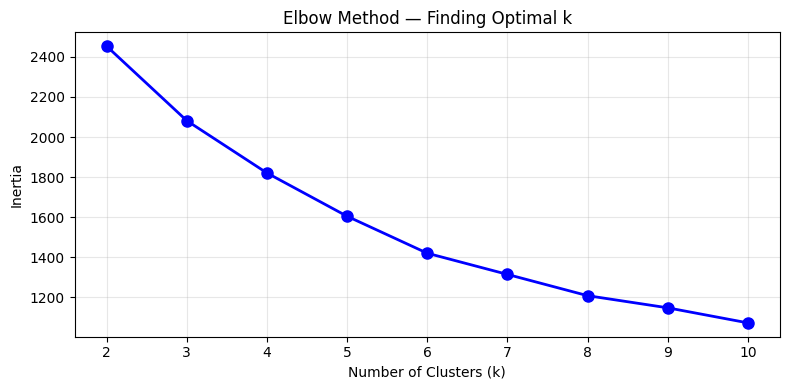

Inertia values: {2: 2453.1, 3: 2081.5, 4: 1820.7, 5: 1604.8, 6: 1420.5, 7: 1314.8, 8: 1208.7, 9: 1148.2, 10: 1073.0}


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features for clustering
features = ['Is_Military', 'Gender_enc', 'Major_cat', 
            'Selection_Age', 'Space Flights', 'Space Flight (hr)', 
            'Space Walks', 'Space Walks (hr)', 'Hrs_per_flight']

X = df[features].dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method — find optimal k
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot elbow
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal k')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Inertia values:", dict(zip(k_range, [round(i,1) for i in inertias])))

In [10]:
# Fit final KMeans with k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

# See how many astronauts in each cluster
print("Astronauts per cluster:")
print(df['Cluster'].value_counts().sort_index())

# See the average profile of each cluster
cluster_profile = df.groupby('Cluster')[features].mean().round(2)
print("\nCluster Profiles (mean values):")
print(cluster_profile)

Astronauts per cluster:
Cluster
0     47
1    226
2     40
3     44
Name: count, dtype: int64

Cluster Profiles (mean values):
         Is_Military  Gender_enc  Major_cat  Selection_Age  Space Flights  \
Cluster                                                                     
0               0.26        0.00       1.53          33.11           2.40   
1               0.71        1.00       1.19          35.34           2.07   
2               0.57        0.92       1.12          36.20           2.80   
3               0.34        1.00       1.09          33.93           3.43   

         Space Flight (hr)  Space Walks  Space Walks (hr)  Hrs_per_flight  
Cluster                                                                    
0                  1168.40         0.28              2.19          325.98  
1                   552.79         0.33              1.71          160.27  
2                  5577.28         4.00             24.85         1526.80  
3                   978.45    

In [11]:
# Name the archetypes
archetype_names = {
    0: 'Women Pioneers',
    1: 'Standard Military Corps',
    2: 'Elite Long-Duration Flyers',
    3: 'Spacewalk Specialists'
}

df['Archetype'] = df['Cluster'].map(archetype_names)

# Show sample astronauts from each archetype
for archetype in archetype_names.values():
    print(f"\n {archetype} ")
    sample = df[df['Archetype'] == archetype][['Name', 'Space Flights', 
                  'Space Flight (hr)', 'Space Walks', 'Is_Military']].head(4)
    print(sample.to_string(index=False))


 Women Pioneers 
           Name  Space Flights  Space Flight (hr)  Space Walks  Is_Military
Serena M. Aunon              0                  0            0            0
 Ellen S. Baker              3                686            0            0
Yvonne D. Cagle              0                  0            0            1
 Kalpana Chawla              2                734            0            0

 Standard Military Corps 
            Name  Space Flights  Space Flight (hr)  Space Walks  Is_Military
  Loren W. Acton              1                190            0            0
James C. Adamson              2                334            0            1
     Buzz Aldrin              2                289            2            1
 Andrew M. Allen              3                906            0            1

 Elite Long-Duration Flyers 
               Name  Space Flights  Space Flight (hr)  Space Walks  Is_Military
    Joseph M. Acaba              2               3307            2            0


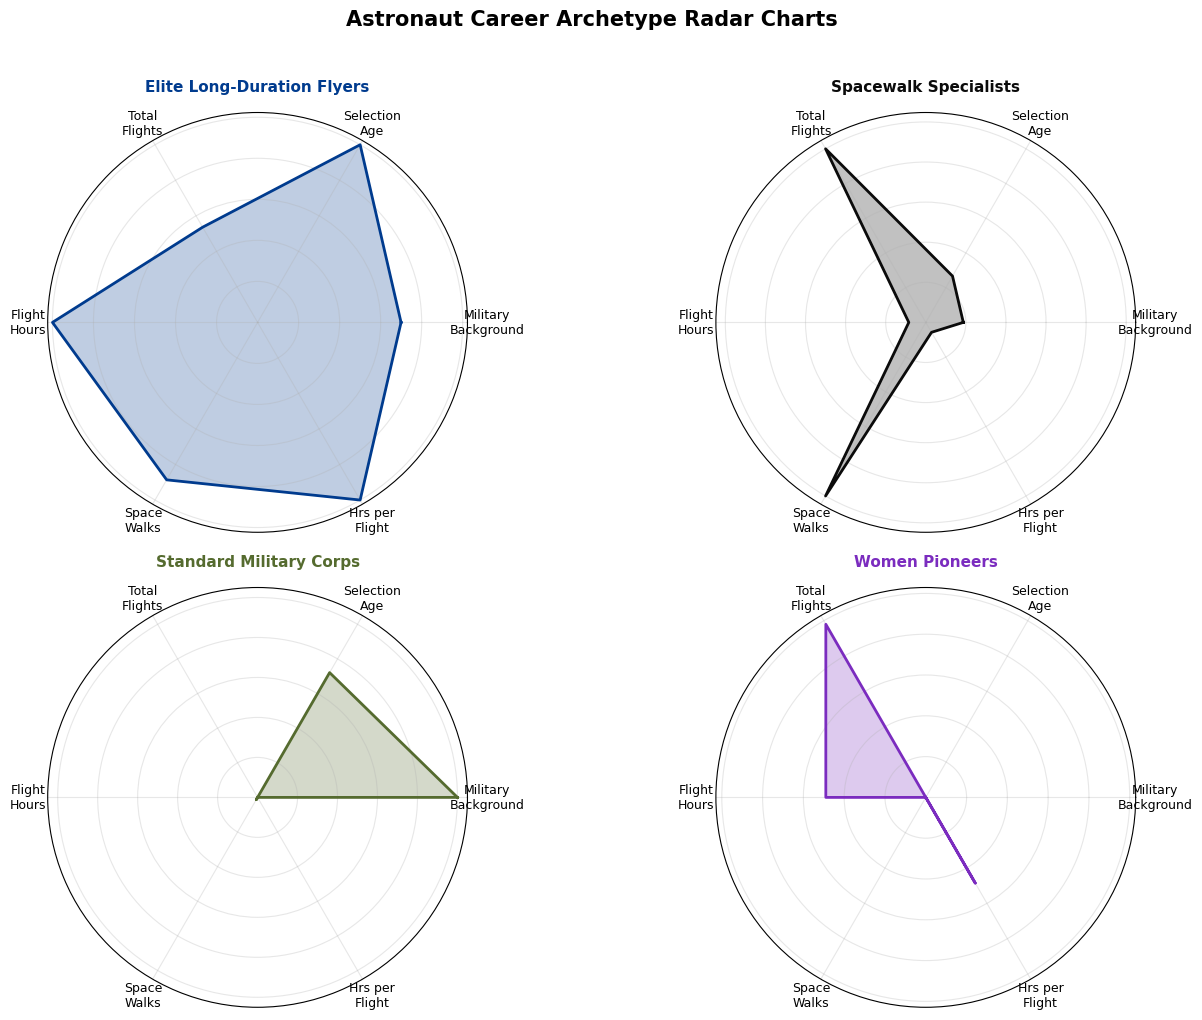

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Normalize profiles for radar chart (0 to 1 scale)
radar_features = ['Is_Military', 'Selection_Age', 'Space Flights', 
                  'Space Flight (hr)', 'Space Walks', 'Hrs_per_flight']

profile = df.groupby('Archetype')[radar_features].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

# Radar setup
labels = ['Military\nBackground', 'Selection\nAge', 'Total\nFlights', 
          'Flight\nHours', 'Space\nWalks', 'Hrs per\nFlight']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the circle

colors = ['#003B8E', '#0B0B0B', '#556B2F', '#7B2CBF']
archetypes = profile_norm.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, (archetype, color) in enumerate(zip(archetypes, colors)):
    values = profile_norm.loc[archetype].tolist()
    values += values[:1]
    
    ax = axes[i]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_yticklabels([])
    ax.set_title(archetype, size=11, fontweight='bold', pad=15, color=color)
    ax.grid(True, alpha=0.3)

plt.suptitle('Astronaut Career Archetype Radar Charts', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\nvija\Downloads\Portfolio\astronaut career dna\career_dna_radar.png', 
            dpi=150, bbox_inches='tight')
plt.show()

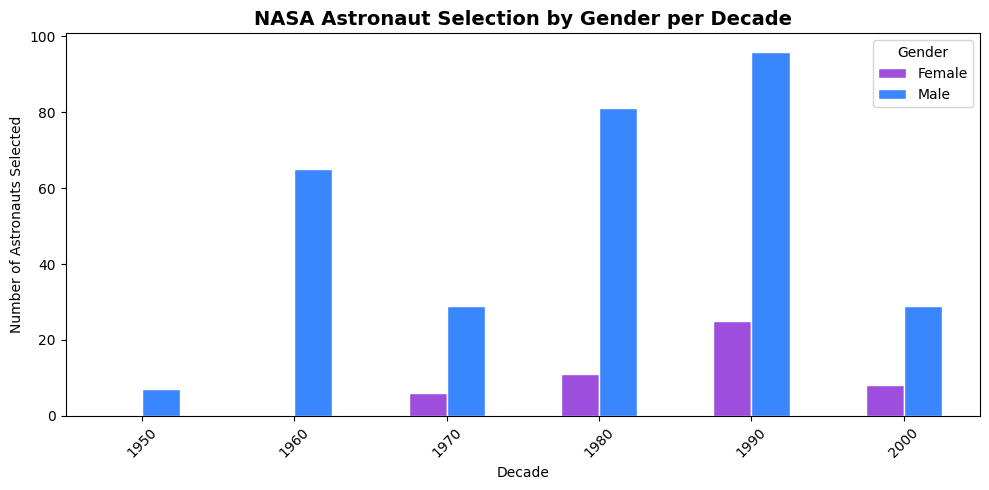

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert year to decade
df['Decade'] = (df['Year'] // 10 * 10).astype(int)

decade_gender = df.groupby(['Decade', 'Gender']).size().unstack(fill_value=0)

decade_gender.plot(kind='bar', figsize=(10, 5), 
                   color=['#9D4EDD', '#3A86FF'], edgecolor='white')
plt.title('NASA Astronaut Selection by Gender per Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Number of Astronauts Selected')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig(r'C:\Users\nvija\Downloads\Portfolio\astronaut career dna\gender_by_decade.png', dpi=150)
plt.show()

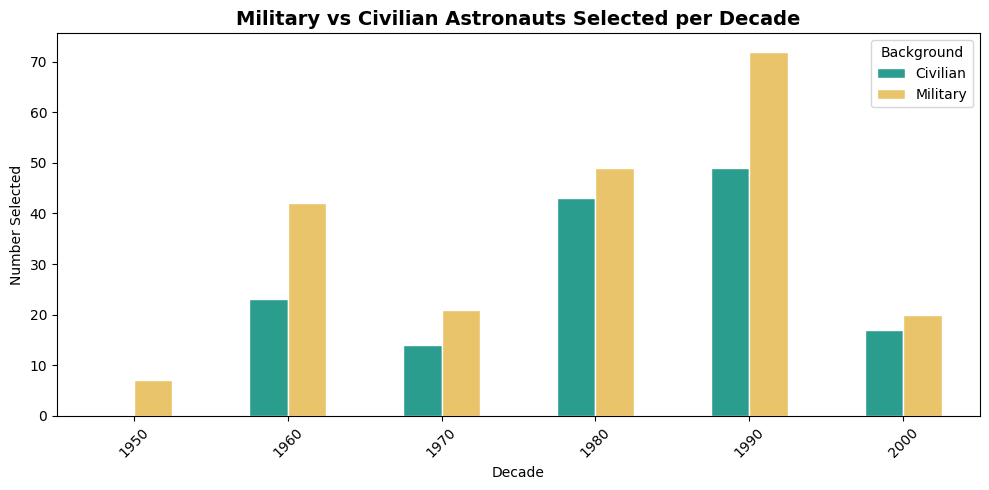

In [20]:
mil_trend = df.groupby(['Decade', 'Is_Military']).size().unstack(fill_value=0)
mil_trend.columns = ['Civilian', 'Military']

mil_trend.plot(kind='bar', figsize=(10, 5),
               color=['#2A9D8F', '#E9C46A'], edgecolor='white')
plt.title('Military vs Civilian Astronauts Selected per Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Number Selected')
plt.xticks(rotation=45)
plt.legend(title='Background')
plt.tight_layout()
plt.savefig(r'C:\Users\nvija\Downloads\Portfolio\astronaut career dna\military_vs_civilian.png', dpi=150)
plt.show()

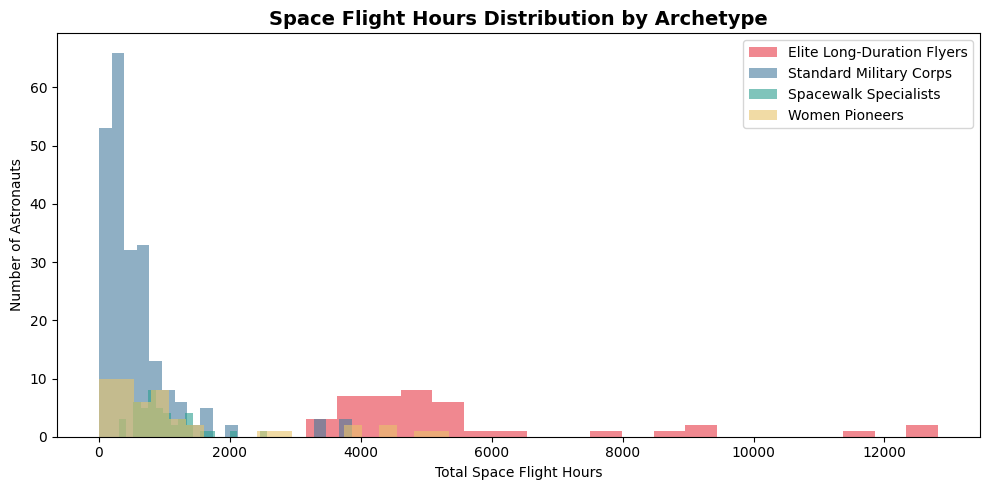

In [15]:
plt.figure(figsize=(10, 5))
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']

for i, (archetype, color) in enumerate(zip(df['Archetype'].unique(), colors)):
    subset = df[df['Archetype'] == archetype]['Space Flight (hr)']
    plt.hist(subset, bins=20, alpha=0.6, label=archetype, color=color)

plt.title('Space Flight Hours Distribution by Archetype', fontsize=14, fontweight='bold')
plt.xlabel('Total Space Flight Hours')
plt.ylabel('Number of Astronauts')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\nvija\Downloads\Portfolio\astronaut career dna\hours_distribution.png', dpi=150)
plt.show()

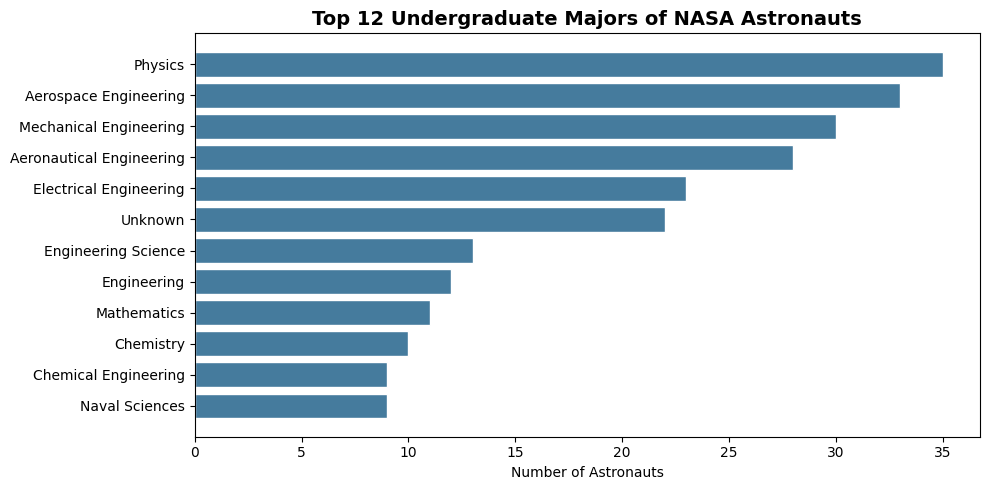

In [16]:
top_majors = df['Undergraduate Major'].value_counts().head(12)

plt.figure(figsize=(10, 5))
bars = plt.barh(top_majors.index[::-1], top_majors.values[::-1], 
                color='#457B9D', edgecolor='white')
plt.title('Top 12 Undergraduate Majors of NASA Astronauts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Astronauts')
plt.tight_layout()
plt.savefig(r'C:\Users\nvija\Downloads\Portfolio\astronaut career dna\top_majors.png', dpi=150)
plt.show()

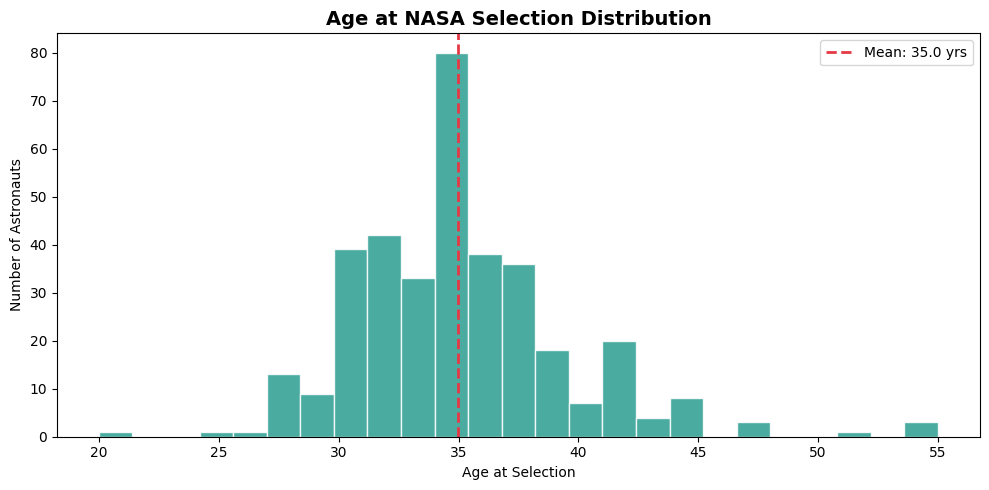

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df['Selection_Age'].dropna(), bins=25, color='#2A9D8F', 
         edgecolor='white', alpha=0.85)
plt.axvline(df['Selection_Age'].mean(), color='#E63946', 
            linestyle='--', linewidth=2, label=f"Mean: {df['Selection_Age'].mean():.1f} yrs")
plt.title('Age at NASA Selection Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age at Selection')
plt.ylabel('Number of Astronauts')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\nvija\Downloads\Portfolio\astronaut career dna\selection_age.png', dpi=150)
plt.show()

In [18]:
print(""" 
KEY FINDINGS: NASA Astronaut Career DNA

1. PHYSICS BEATS ENGINEERING
   The #1 undergraduate major is Physics (35 astronauts), 
   not Aerospace Engineering. NASA values scientific 
   thinking over technical specialization at entry level.

2. THE 35-YEAR SWEET SPOT
   NASA selects astronauts at a mean age of 35.0 years.
   Too young = insufficient experience. Too old = career 
   too short. The window is roughly 28-42 years.

3. CIVILIAN RISE
   From 1950-1970, military candidates dominated completely.
   By the 1990s, civilian scientists nearly matched military 
   selections, reflecting NASA's shift from test pilots 
   to mission specialists.

4. GENDER BREAKTHROUGH IN THE 1980s
   Zero women were selected before 1978. The 1990s saw 
   the highest female intake ever — 25 women in one decade.

5. THE ELITE 11% CLUB
   Only 40 of 357 astronauts (11%) became Elite Long-Duration 
   Flyers, averaging 5,577 hours in space. These ISS veterans 
   logged 10x more hours than the standard military corps.

6. SPACEWALK SPECIALISTS ARE REPEAT FLYERS
   With 3.43 average missions and 4.48 spacewalks, this 
   archetype shows NASA deliberately re-selects proven 
   EVA performers for complex assembly missions.
""")

 
KEY FINDINGS: NASA Astronaut Career DNA

1. PHYSICS BEATS ENGINEERING
   The #1 undergraduate major is Physics (35 astronauts), 
   not Aerospace Engineering. NASA values scientific 
   thinking over technical specialization at entry level.

2. THE 35-YEAR SWEET SPOT
   NASA selects astronauts at a mean age of 35.0 years.
   Too young = insufficient experience. Too old = career 
   too short. The window is roughly 28-42 years.

3. CIVILIAN RISE
   From 1950-1970, military candidates dominated completely.
   By the 1990s, civilian scientists nearly matched military 
   selections — reflecting NASA's shift from test pilots 
   to mission specialists.

4. GENDER BREAKTHROUGH IN THE 1980s
   Zero women were selected before 1978. The 1990s saw 
   the highest female intake ever — 25 women in one decade.

5. THE ELITE 11% CLUB
   Only 40 of 357 astronauts (11%) became Elite Long-Duration 
   Flyers — averaging 5,577 hours in space. These ISS veterans 
   logged 10x more hours than the stan